# 04. 세션 퍼널 초기 진단

## 1. 분석 목적·단위·해석 기준

- 목적: 같은 세션 안에서 `view → cart → purchase`가 시간순으로 이어지는 규모를 세션과 세션·상품 단위로 진단하고, 세션 경계만으로 전체 구매 여정을 설명하기 어려운 이유를 확인한다.
- 세션 퍼널 분석 단위: `user_session`. 상품 동일성을 요구하지 않는 세션 단위 초기 진단이다.
- 세션·상품 퍼널 분석 단위: `user_session × product_id`. 같은 세션·같은 상품에서 `view_at < cart_at < purchase_at`을 만족해야 한다.
- 시간 순서 조건: 동일 시각 이벤트의 선후는 정하지 않으며 뒤 단계에 포함하지 않는다. 각 단계의 분자는 직전 단계 분모의 부분집합이다.
- 해석 범위: 두 퍼널은 단위와 상품 동일성 조건이 다르므로 서로 직접 비교하지 않는다. 여러 세션을 합친 `user_id × product_id` 30일 대표 첫 구매 분석과도 분모·관측창이 달라 비율을 직접 비교하지 않는다.
- 후속 분석: 05는 최초 view 이후 30일을 모두 관측할 수 있는 사용자·상품에서 실제 이벤트 시각으로 대표 첫 구매와 네 경로를 재구성한다.

In [1]:
import os
import sys
from pathlib import Path
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}?charset=utf8mb4"
)
pio.renderers.default = 'plotly_mimetype'
COLORS = {'view': '#3B82F6', 'cart': '#F59E0B', 'purchase': '#10B981', 'neutral': '#94A3B8'}

In [2]:
def find_project_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / 'cache_context.json').is_file() and (base / 'sql').is_dir():
            return base
    raise FileNotFoundError(f'프로젝트 루트 없음 (cwd={Path.cwd()})')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from query_cache import QueryCache, load_queries

SQL_FILE = PROJECT_ROOT / 'sql' / '04_funnel_eda.sql'
Q = load_queries(SQL_FILE)
QUERY_CACHE = QueryCache(
    engine=engine,
    sql_file=SQL_FILE,
    upstream_sql_files=(PROJECT_ROOT / 'sql' / '02_preprocessing_mart.sql',),
)

def run(name, refresh=False, **kwargs):
    return QUERY_CACHE.run(name, refresh=refresh, **kwargs)

def build_funnel_table(result, total_column, count_column):
    row = result.iloc[0]
    total = int(row[total_column])
    counts = [int(row['view_도달']), int(row['view_cart_순차']), int(row['view_cart_purchase_순차'])]
    assert counts[2] <= counts[1] <= counts[0] <= total
    frame = pd.DataFrame({
        '단계': ['조회가 있는 조합', '조회 이후 장바구니 담기', '조회→담기 이후 구매'],
        count_column: counts,
    })
    frame['전체분모대비_pct'] = frame[count_column] / total * 100
    frame['직전단계전환율_pct'] = [
        counts[0] / total * 100,
        counts[1] / counts[0] * 100,
        counts[2] / counts[1] * 100,
    ]
    return frame, total

---
## 2. 세션 단위 순차 퍼널

분석 단위는 `user_session`이다. 유효 세션 전체를 분모로 두고, 조회가 있는 세션 → 같은 세션에서 조회 이후 장바구니 담기가 확인된 세션 → 그 순서 뒤에 구매가 확인된 세션을 센다. 상품 동일성을 요구하지 않으므로 세션 안의 서로 다른 상품 행동이 한 퍼널에 포함될 수 있다.

In [3]:
session_result = run('fn_session_funnel')
session_funnel, valid_session_n = build_funnel_table(
    session_result, '유효세션', '세션 수'
)
session_view_n, session_cart_n, session_purchase_n = session_funnel['세션 수'].tolist()
session_completion_rate = session_purchase_n / session_view_n * 100
display(session_funnel.round(3))

[fn_session_funnel] cache HIT 0dc1fbad25c0 · 1행


,단계,세션 수,전체분모대비_pct,직전단계전환율_pct
0,조회가 있는 조합,4245334,94.352,94.352
1,조회 이후 장바구니 담기,710008,15.780,16.724
2,조회→담기 이후 구매,97600,2.169,13.746


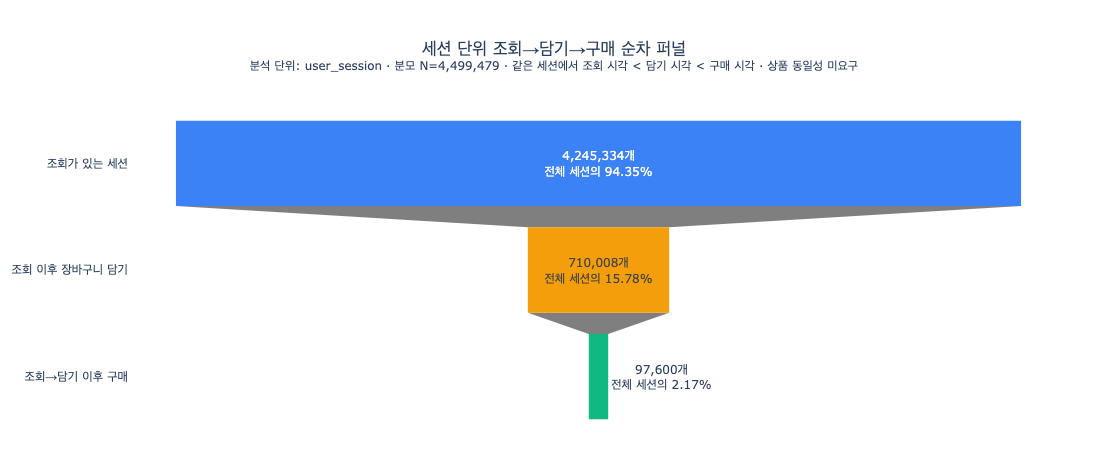

In [4]:
session_text = [
    f"{count:,}개<br>전체 세션의 {rate:.2f}%"
    for count, rate in zip(session_funnel['세션 수'], session_funnel['전체분모대비_pct'])
]
fig = go.Figure(go.Funnel(
    y=['조회가 있는 세션', '조회 이후 장바구니 담기', '조회→담기 이후 구매'],
    x=session_funnel['세션 수'],
    text=session_text,
    texttemplate='%{text}',
    marker=dict(color=[COLORS['view'], COLORS['cart'], COLORS['purchase']]),
    hovertemplate='%{y}<br>%{value:,}개<extra></extra>',
))
fig.update_layout(
    title=dict(
        text=(
            '세션 단위 조회→담기→구매 순차 퍼널'
            f'<br><sup>분석 단위: user_session · 분모 N={valid_session_n:,} · 같은 세션에서 조회 시각 &lt; 담기 시각 &lt; 구매 시각 · 상품 동일성 미요구</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    paper_bgcolor='white', plot_bgcolor='white', height=470,
    margin=dict(l=40, r=40, t=110, b=40),
)
fig.show()

> ### 섹션 결론
>
> - 유효 세션 4,499,479개 중 조회가 있는 세션은 4,245,334개다. 조회 세션 중 710,008개가 조회 이후 장바구니 담기로 넘어가 직전 단계 전환율은 16.724%다.
> - 조회→담기 순서대로 이어진 건 710,008개 중 97,600개에서 그 이후 구매가 확인돼 직전 단계 전환율은 13.746%다. 조회 세션 4,245,334개를 분모로 한 조회→담기→구매 전 구간 전환율은 16.724% × 13.746% = 2.299%다. 표의 `전체분모대비_pct` 2.169%는 유효 세션 4,499,479개를 분모로 한 값이라 다르다.
> - 이 값은 상품 동일성을 요구하지 않는 세션 단위 초기 진단이며, 사용자·상품 단위의 대표 첫 구매율로 해석하지 않는다.

---
## 3. 세션·상품 단위 순차 퍼널

분석 단위는 `user_session × product_id`다. 같은 세션·같은 상품에서 조회보다 늦은 장바구니 담기와, 그 담기보다 늦은 구매가 차례로 확인돼야 한다. 세션 퍼널보다 상품 조건이 엄격하고 분모도 다르므로 두 퍼널의 차이를 증감률로 계산하지 않는다.

In [5]:
product_result = run('fn_product_funnel')
product_funnel, session_product_n = build_funnel_table(
    product_result, 'session_product수', '세션·상품 수'
)
product_view_n, product_cart_n, product_purchase_n = product_funnel['세션·상품 수'].tolist()
product_completion_rate = product_purchase_n / product_view_n * 100
display(product_funnel.round(3))

[fn_product_funnel] cache HIT ce2a62bf2666 · 1행


,단계,세션·상품 수,전체분모대비_pct,직전단계전환율_pct
0,조회가 있는 조합,8082190,66.784,66.784
1,조회 이후 장바구니 담기,885651,7.318,10.958
2,조회→담기 이후 구매,132235,1.093,14.931


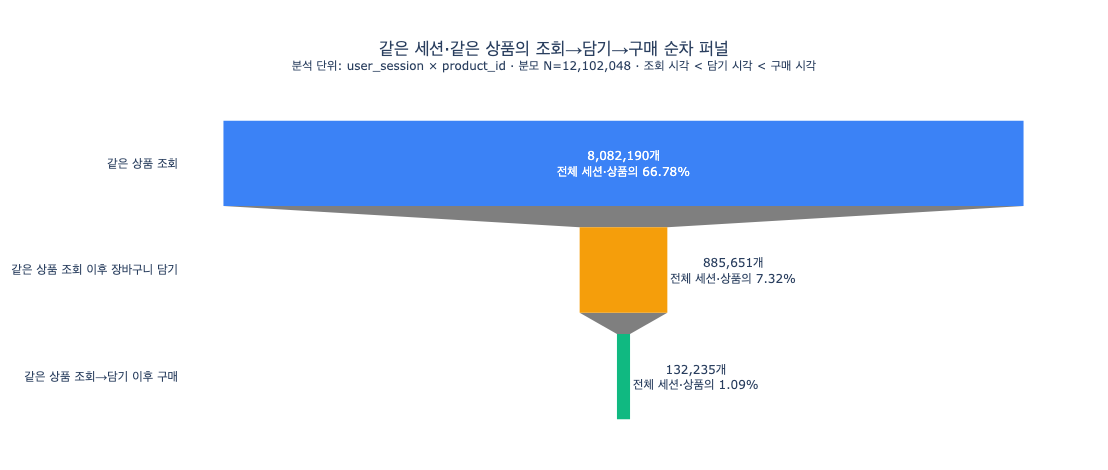

In [6]:
product_text = [
    f"{count:,}개<br>전체 세션·상품의 {rate:.2f}%"
    for count, rate in zip(product_funnel['세션·상품 수'], product_funnel['전체분모대비_pct'])
]
fig = go.Figure(go.Funnel(
    y=['같은 상품 조회', '같은 상품 조회 이후 장바구니 담기', '같은 상품 조회→담기 이후 구매'],
    x=product_funnel['세션·상품 수'],
    text=product_text,
    texttemplate='%{text}',
    marker=dict(color=[COLORS['view'], COLORS['cart'], COLORS['purchase']]),
    hovertemplate='%{y}<br>%{value:,}개<extra></extra>',
))
fig.update_layout(
    title=dict(
        text=(
            '같은 세션·같은 상품의 조회→담기→구매 순차 퍼널'
            f'<br><sup>분석 단위: user_session × product_id · 분모 N={session_product_n:,} · 조회 시각 &lt; 담기 시각 &lt; 구매 시각</sup>'
        ),
        x=0.5, xanchor='center',
    ),
    paper_bgcolor='white', plot_bgcolor='white', height=470,
    margin=dict(l=40, r=40, t=110, b=40),
)
fig.show()

> ### 섹션 결론
>
> - 전체 세션·상품 12,102,048개 중 같은 상품 조회가 있는 조합은 8,082,190개다. 이 중 885,651개가 같은 상품의 조회 이후 장바구니 담기로 넘어가 직전 단계 전환율은 10.958%다.
> - 조회→담기 순서대로 이어진 조합 중 132,235개에서 그 이후 같은 상품 구매가 확인돼 직전 단계 전환율은 14.931%다. 같은 상품 조회 조합 8,082,190개를 분모로 한 조회→담기→구매 전 구간 전환율은 10.958% × 14.931% = 1.636%다. 표의 `전체분모대비_pct` 1.093%는 전체 세션·상품 12,102,048개를 분모로 한 값이라 다르다.
> - 이 퍼널도 한 세션 안에서 완결된 경로만 포함한다. 다른 세션의 조회·담기와 연결된 구매는 이 결과에 포함되지 않는다.

---
## 4. 세션 경계만으로 여정을 설명하기 어려운 이유

세션 퍼널 안에서 순서를 완성하지 못한 경계 사례와, 동일 사용자·상품이 여러 세션에서 관찰되는 규모를 함께 확인한다.

- 세션 퍼널 경계: 같은 세션에서 조회가 관찰되지 않았거나 조회와 담기의 시간 순서를 확인할 수 없는 세션을 센다.
- 반복 관찰 규모: 같은 `user_id × product_id`가 몇 개 세션에 나타났는지 센다.

이 값들은 구매 경로 비중이 아니라 한 세션 안의 퍼널만으로 전체 여정을 설명할 수 있는지 확인하는 경계 진단이다.

In [7]:
boundary = run('fn_boundary').iloc[0]
scope = run('fn_user_product_session_scope')

scope_total = int(scope['사용자상품_조합수'].sum())
scope_multi = int(scope.loc[scope['관측세션구간'].ne('1세션'), '사용자상품_조합수'].sum())
scope_session_product_total = int(scope['세션상품_조합수'].sum())
scope_multi_session_products = int(scope.loc[scope['관측세션구간'].ne('1세션'), '세션상품_조합수'].sum())

assert int(boundary['유효세션']) == valid_session_n
assert scope_session_product_total == session_product_n

boundary_summary = pd.DataFrame({
    '진단 항목': [
        'view 미관찰 cart 세션',
        'view 미관찰 purchase 세션',
        'view·cart 동반이나 순서 미확인 세션',
        '2개 이상 세션에서 관찰된 사용자·상품',
        '해당 사용자·상품의 세션·상품 기록',
    ],
    '건수': [
        int(boundary['view없이_cart']),
        int(boundary['view없이_purchase']),
        int(boundary['view_cart있으나_순서미확인']),
        scope_multi, scope_multi_session_products,
    ],
    '분모 N': [
        valid_session_n, valid_session_n, valid_session_n,
        scope_total, scope_session_product_total,
    ],
    '분모 대비 비율(%)': [
        int(boundary['view없이_cart']) / valid_session_n * 100,
        int(boundary['view없이_purchase']) / valid_session_n * 100,
        int(boundary['view_cart있으나_순서미확인']) / valid_session_n * 100,
        scope_multi / scope_total * 100,
        scope_multi_session_products / scope_session_product_total * 100,
    ],
})
display(boundary_summary.round(3))

[fn_boundary] cache HIT 2500a9795274 · 1행
[fn_user_product_session_scope] cache HIT 972d46a36c60 · 4행


,진단 항목,건수,분모 N,분모 대비 비율(%)
0,view 미관찰 cart 세션,196424,4499479,4.365
1,view 미관찰 purchase 세션,39015,4499479,0.867
2,view·cart 동반이나 순서 미확인 세션,63525,4499479,1.412
3,2개 이상 세션에서 관찰된 사용자·상품,1650615,9613024,17.171
4,해당 사용자·상품의 세션·상품 기록,4139639,12102048,34.206


> ### 섹션 결론
>
> - 사용자·상품 9,613,024개 중 1,650,615개(17.171%)가 여러 세션에 걸쳐 관찰됐고, 해당 집단의 세션·상품 기록은 4,139,639개(34.206%)다.
> - 동일 사용자·상품의 17.171%가 여러 세션에 걸쳐 관찰됐으므로, 한 세션 안의 퍼널만으로 전체 구매 여정을 설명하기 어렵다. 후속 분석에서는 사용자·상품 단위로 세션을 연결하고 실제 이벤트 시각을 사용한다.

---
## 5. 결론과 대표 첫 구매 분석으로의 인계

> ### 섹션 결론
>
> - 세션 단위에서 조회 세션의 2.299%가 조회→담기→구매 순서를 끝까지 이어갔고, 같은 세션·같은 상품 조회 조합에서는 1.636%가 3단계를 끝까지 이어갔다. 두 값은 분모와 상품 조건이 달라 직접 비교하지 않는다.
> - 동일 사용자·상품의 17.171%가 여러 세션에 걸쳐 관찰됐으므로, 한 세션 안의 퍼널만으로 전체 구매 여정을 설명하기 어렵다.
> - 04는 동일 세션 안에서 확인되는 퍼널 구조와 세션 경계의 한계까지만 제시한다. 구매 여정의 최종 해석은 05에서 최초 view 이후 30일 cohort, 실제 이벤트 시각, 대표 첫 구매를 기준으로 수행한다.
> - 관찰 데이터에서 확인한 경로 차이는 인과 효과가 아니다. 개선안의 성과는 05의 후속 A/B 테스트 설계로 별도 검증해야 한다.